# Phase 2: Data Understanding

**CRISP-DM Phase Description:**  
This phase involves acquiring the data, getting familiar with it, identifying data quality problems, and detecting initial insights. A thorough understanding of the data at this stage is critical for a successful project.

---

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [52]:

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')
%matplotlib inline

---
### Task 1: Collect Initial Data

Acquire the necessary data and load it into the analysis environment. This task includes:

- **Data Acquisition:** Load data from files, databases, APIs, or other sources.
- **Initial Data Report:** Document the data source(s), the method of acquisition, and any problems encountered during loading.

**Instructions:**
1. Update the file path(s) below to point to your actual dataset(s).
2. Load the data into a Pandas DataFrame.
3. Display a small sample of the data to confirm it loaded correctly.

In [53]:
DATA_PATH = "Train_data.csv"

import pandas as pd

df = pd.read_csv(DATA_PATH)
df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,0.0,0.0,0.0,0.0,1.00,0.00,0.00,150,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,1,0.0,0.0,0.0,0.0,0.08,0.15,0.00,255,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,123,6,1.0,1.0,0.0,0.0,0.05,0.07,0.00,255,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,anomaly
3,0,tcp,http,SF,232,8153,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,5,5,0.2,0.2,0.0,0.0,1.00,0.00,0.00,30,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,30,32,0.0,0.0,0.0,0.0,1.00,0.00,0.09,255,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


In [54]:
print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.sample(5)

Dataset shape: 25192 rows x 42 columns


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
22085,0,udp,domain_u,SF,45,45,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,130,212,0.0,0.0,0.0,0.0,1.00,0.00,0.02,255,254,1.00,0.01,0.01,0.00,0.0,0.0,0.0,0.00,normal
14164,0,tcp,http,SF,348,277,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,2,2,0.0,0.0,0.0,0.0,1.00,0.00,0.00,141,255,1.00,0.00,0.01,0.07,0.0,0.0,0.0,0.00,normal
23684,0,tcp,http,REJ,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0.0,0.0,1.0,1.0,1.00,0.00,0.00,10,255,1.00,0.00,0.10,0.10,0.0,0.0,1.0,0.98,normal
4668,0,icmp,eco_i,SF,18,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0.0,0.0,0.0,0.0,1.00,0.00,0.00,1,80,1.00,0.00,1.00,1.00,0.0,0.0,0.0,0.00,anomaly
775,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,134,16,1.0,1.0,0.0,0.0,0.12,0.07,0.00,255,17,0.07,0.06,0.00,0.00,1.0,1.0,0.0,0.00,anomaly


In [55]:
data_source_report = {
    "source": "Kaggle",
    "acquisition_method": "CSV download",
    "date_acquired": "2026",
    "issues_encountered": [
        "Possible class imbalance in intrusion vs normal data",
        "Some categorical features may require encoding",
        "Potential missing or noisy values"
    ]
}

print(data_source_report)

{'source': 'Kaggle', 'acquisition_method': 'CSV download', 'date_acquired': '2026', 'issues_encountered': ['Possible class imbalance in intrusion vs normal data', 'Some categorical features may require encoding', 'Potential missing or noisy values']}


---
### Task 2: Describe Data

Examine the "surface" properties of the acquired data. This includes:

- **Volume:** How many records (rows) and attributes (columns) does the dataset contain?
- **Field Identities:** What are the names, data types, and roles (ID, feature, target) of each column?
- **Descriptive Statistics:** What are the basic statistics (mean, median, std, min, max) of the numerical features and frequency counts for categorical features?

**Instructions:** Use Pandas built-in methods (`.info()`, `.describe()`, `.dtypes`, `.value_counts()`) to generate a comprehensive description of your data.

In [56]:
# TODO: Describe the structure and schema of your data.
# Inspect data types, non-null counts, and memory usage.

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25192 entries, 0 to 25191
Data columns (total 42 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   duration                     25192 non-null  int64  
 1   protocol_type                25192 non-null  object 
 2   service                      25192 non-null  object 
 3   flag                         25192 non-null  object 
 4   src_bytes                    25192 non-null  int64  
 5   dst_bytes                    25192 non-null  int64  
 6   land                         25192 non-null  int64  
 7   wrong_fragment               25192 non-null  int64  
 8   urgent                       25192 non-null  int64  
 9   hot                          25192 non-null  int64  
 10  num_failed_logins            25192 non-null  int64  
 11  logged_in                    25192 non-null  int64  
 12  num_compromised              25192 non-null  int64  
 13  root_shell      

In [57]:
# Generate descriptive statistics for numerical columns
# df.describe()
df.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
count,25192.000000,2.519200e+04,2.519200e+04,25192.000000,25192.000000,25192.00000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.0,25192.0,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000
mean,305.054104,2.433063e+04,3.491847e+03,0.000079,0.023738,0.00004,0.198039,0.001191,0.394768,0.227850,0.001548,0.001350,0.249841,0.014727,0.000357,0.004327,0.0,0.0,0.009130,84.591180,27.698754,0.286338,0.283762,0.118630,0.120260,0.660559,0.062363,0.095931,182.532074,115.063036,0.519791,0.082539,0.147453,0.031844,0.285800,0.279846,0.117800,0.118769
std,2686.555640,2.410805e+06,8.883072e+04,0.008910,0.260221,0.00630,2.154202,0.045418,0.488811,10.417352,0.039316,0.048785,11.500842,0.529602,0.018898,0.098524,0.0,0.0,0.095115,114.673451,72.468242,0.447312,0.447599,0.318745,0.322335,0.439637,0.178550,0.256583,98.993895,110.646850,0.448944,0.187191,0.308367,0.110575,0.445316,0.446075,0.305869,0.317333
min,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.090000,0.000000,0.000000,84.000000,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,14.000000,8.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,255.000000,61.000000,0.510000,0.030000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,2.790000e+02,5.302500e+02,0.000000,0.000000,0.00000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,144.000000,18.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.060000,0.000000,255.000000,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000
max,42862.000000,3.817091e+08,5.151385e+06,1.000000,3.000000,1.00000,77.000000,4.000000,1.000000,884.000000,1.000000,2.000000,975.000000,40.000000,1.000000,8.000000,0.0,0.0,1.000000,511.000000,511.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,255.000000,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [58]:
# Generate descriptive statistics for categorical columns
# df.describe(include='object')

# Or inspect value counts for specific categorical columns:
# for col in df.select_dtypes(include='object').columns:
#     print(f"\n--- {col} ---")
#     print(df[col].value_counts())
df.describe(include='object')
for col in df.select_dtypes(include='object').columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- protocol_type ---
protocol_type
tcp     20526
udp      3011
icmp     1655
Name: count, dtype: int64

--- service ---
service
http           8003
private        4351
domain_u       1820
smtp           1449
ftp_data       1396
eco_i           909
other           858
ecr_i           613
telnet          483
finger          366
ftp             345
auth            189
Z39_50          172
courier         164
uucp            157
time            155
bgp             146
whois           145
imap4           138
uucp_path       133
iso_tsap        131
ctf             127
urp_i           124
nnsp            123
supdup          114
http_443        113
csnet_ns        111
efs             110
domain          109
gopher          109
daytime         107
vmnet           107
discard         105
hostnames        96
name             92
klogin           92
exec             91
ldap             90
mtp              90
systat           88
netbios_dgm      85
link             85
login            79
netstat   

---
### Task 3: Explore Data

Dig deeper into the data using querying, visualisation, and statistical analysis to find initial insights, patterns, and interesting subsets. Key activities include:

- **Univariate Analysis:** Examine the distribution of individual features using histograms, box plots, and bar charts.
- **Bivariate / Multivariate Analysis:** Explore relationships between features using scatter plots, correlation matrices, and grouped summaries.
- **Initial Hypotheses:** Formulate initial hypotheses based on observed patterns.

**Instructions:** Create visualisations and run queries to understand the distributions, relationships, and patterns in your data.

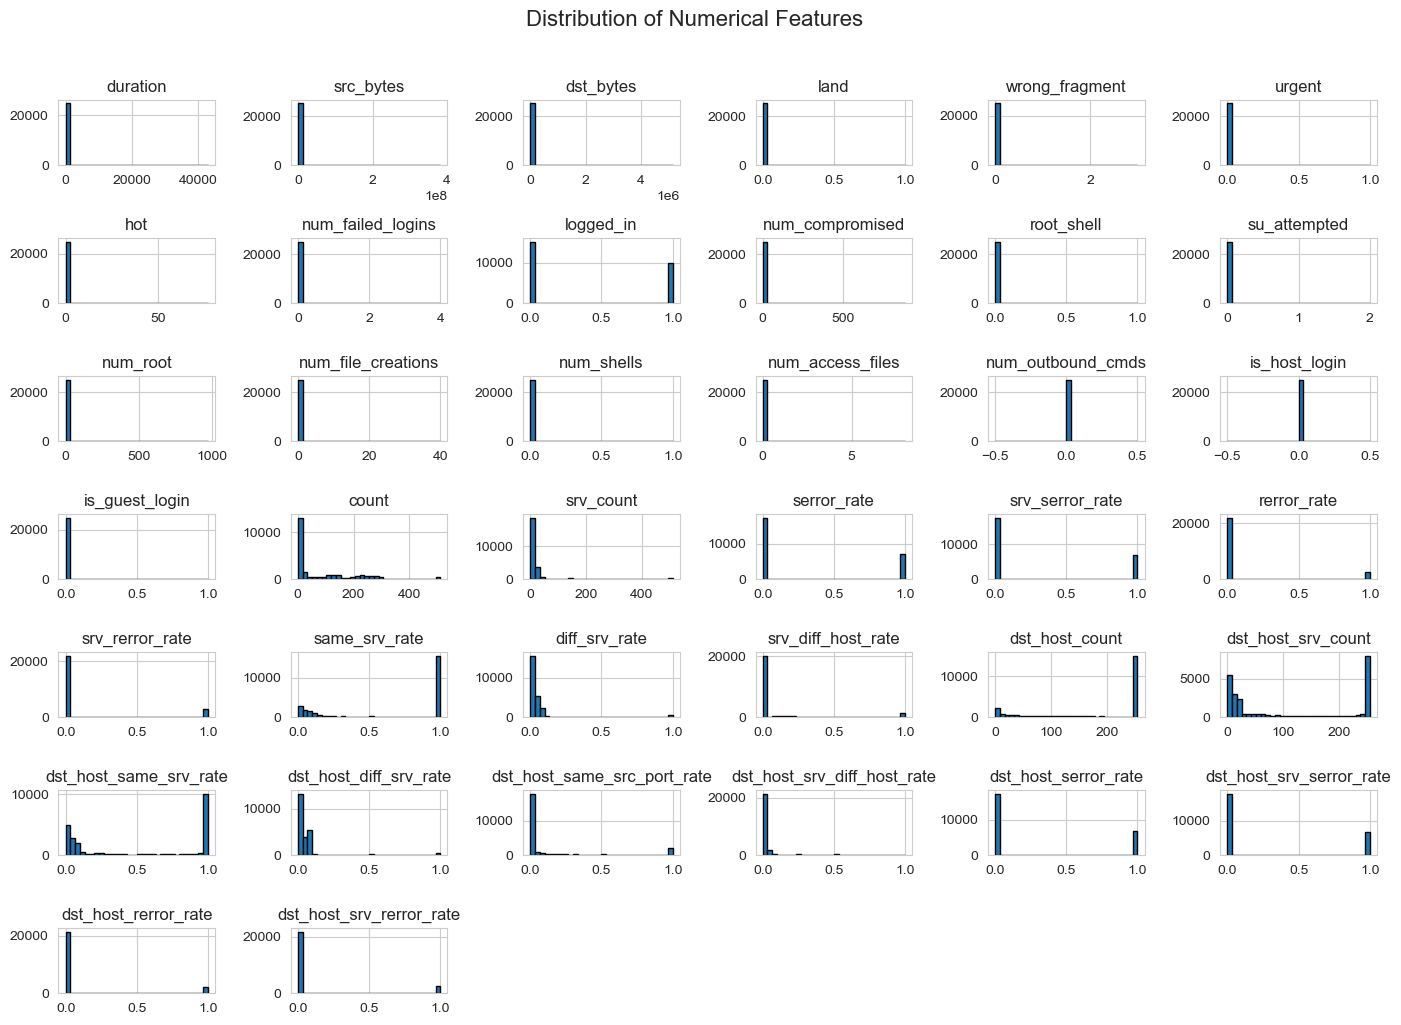

In [59]:
# TODO: Perform univariate analysis — explore distributions of individual features.
# Example: Histograms for numerical columns

df.hist(figsize=(14, 10), bins=30, edgecolor='black')
plt.suptitle('Distribution of Numerical Features', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

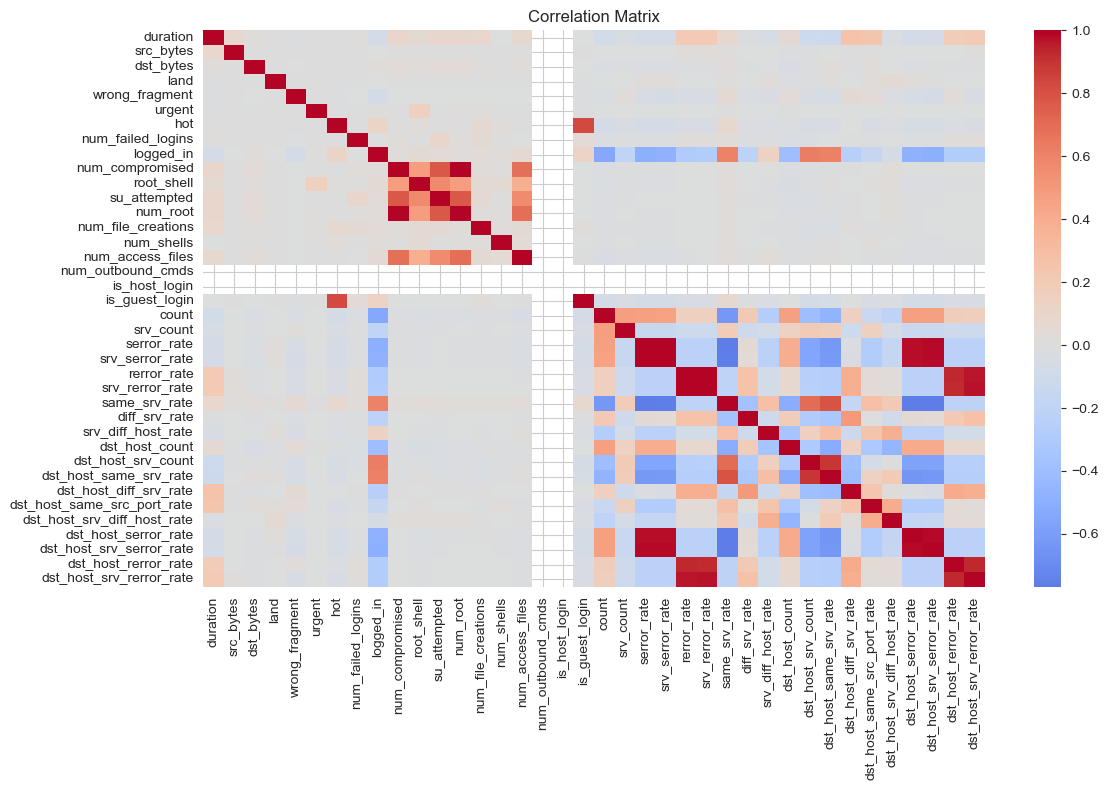

In [60]:
# TODO: Perform bivariate/multivariate analysis — explore relationships between features.
# Example: Correlation heatmap

# plt.figure(figsize=(12, 8))
# correlation_matrix = df.select_dtypes(include=np.number).corr()
# sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
# plt.title('Correlation Matrix')
# plt.tight_layout()
# plt.show()
plt.figure(figsize=(12, 8))
correlation_matrix = df.select_dtypes(include=np.number).corr()

sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [61]:
# TODO: Document any initial insights or hypotheses from your exploration.

# initial_insights = [
#     "Insight 1: ...",
#     "Insight 2: ...",
#     "Hypothesis 1: ..."
# ]
# for i, insight in enumerate(initial_insights, 1):
#     print(f"{i}. {insight}")
initial_insights = [
    "Some numerical features show skewed distributions, indicating the presence of outliers in the dataset",
    
    "Certain features appear to have strong correlations with each other, suggesting possible redundancy or multicollinearity",
    
    "The dataset may be imbalanced, with significantly more normal traffic than attack instances",
    
    "Categorical features such as protocol type and service type show varying frequencies, which may influence classification performance",
    
    "Some features may not contribute significantly to the prediction and could be removed during feature selection",
    
    "Hypothesis: Features related to network traffic behavior (e.g., connection duration, number of bytes) are strong indicators of intrusion activity",
    
    "Hypothesis: Using ensemble models such as Random Forest will perform better than simpler models due to complex feature relationships"
]

for i, insight in enumerate(initial_insights, 1):
    print(f"{i}. {insight}")

1. Some numerical features show skewed distributions, indicating the presence of outliers in the dataset
2. Certain features appear to have strong correlations with each other, suggesting possible redundancy or multicollinearity
3. The dataset may be imbalanced, with significantly more normal traffic than attack instances
4. Categorical features such as protocol type and service type show varying frequencies, which may influence classification performance
5. Some features may not contribute significantly to the prediction and could be removed during feature selection
6. Hypothesis: Features related to network traffic behavior (e.g., connection duration, number of bytes) are strong indicators of intrusion activity
7. Hypothesis: Using ensemble models such as Random Forest will perform better than simpler models due to complex feature relationships


---
### Task 4: Verify Data Quality

Evaluate the completeness and correctness of the data. Check for problems that could affect the analysis:

- **Missing Values:** Identify columns with missing data, the volume, and patterns of missingness.
- **Duplicates:** Check for and report duplicate records.
- **Outliers:** Detect anomalous values using statistical methods or visualisations (box plots, z-scores).
- **Inconsistencies:** Look for data type mismatches, inconsistent formatting, or invalid entries.

**Instructions:** Systematically check for data quality issues and document your findings.

In [62]:
# TODO: Check for missing values.

# missing = df.isnull().sum()
# missing_pct = (df.isnull().sum() / len(df)) * 100
# missing_report = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
# missing_report = missing_report[missing_report['Missing Count'] > 0].sort_values('Missing %', ascending=False)
# print("=== Missing Values Report ===")
# print(missing_report)
# print(f"\nTotal columns with missing values: {len(missing_report)}")
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_report = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})

missing_report = missing_report[missing_report['Missing Count'] > 0]\
                    .sort_values('Missing %', ascending=False)

print("=== Missing Values Report ===")
print(missing_report)

print(f"\nTotal columns with missing values: {len(missing_report)}")

=== Missing Values Report ===
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

Total columns with missing values: 0


In [63]:
# TODO: Check for duplicate records.

# duplicates = df.duplicated().sum()
# print(f"Number of duplicate rows: {duplicates}")
# if duplicates > 0:
#     print("\nSample of duplicate rows:")
#     print(df[df.duplicated(keep=False)].head(10))
duplicates = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicates}")

if duplicates > 0:
    print("\nSample of duplicate rows:")
    print(df[df.duplicated(keep=False)].head(10))

Number of duplicate rows: 0


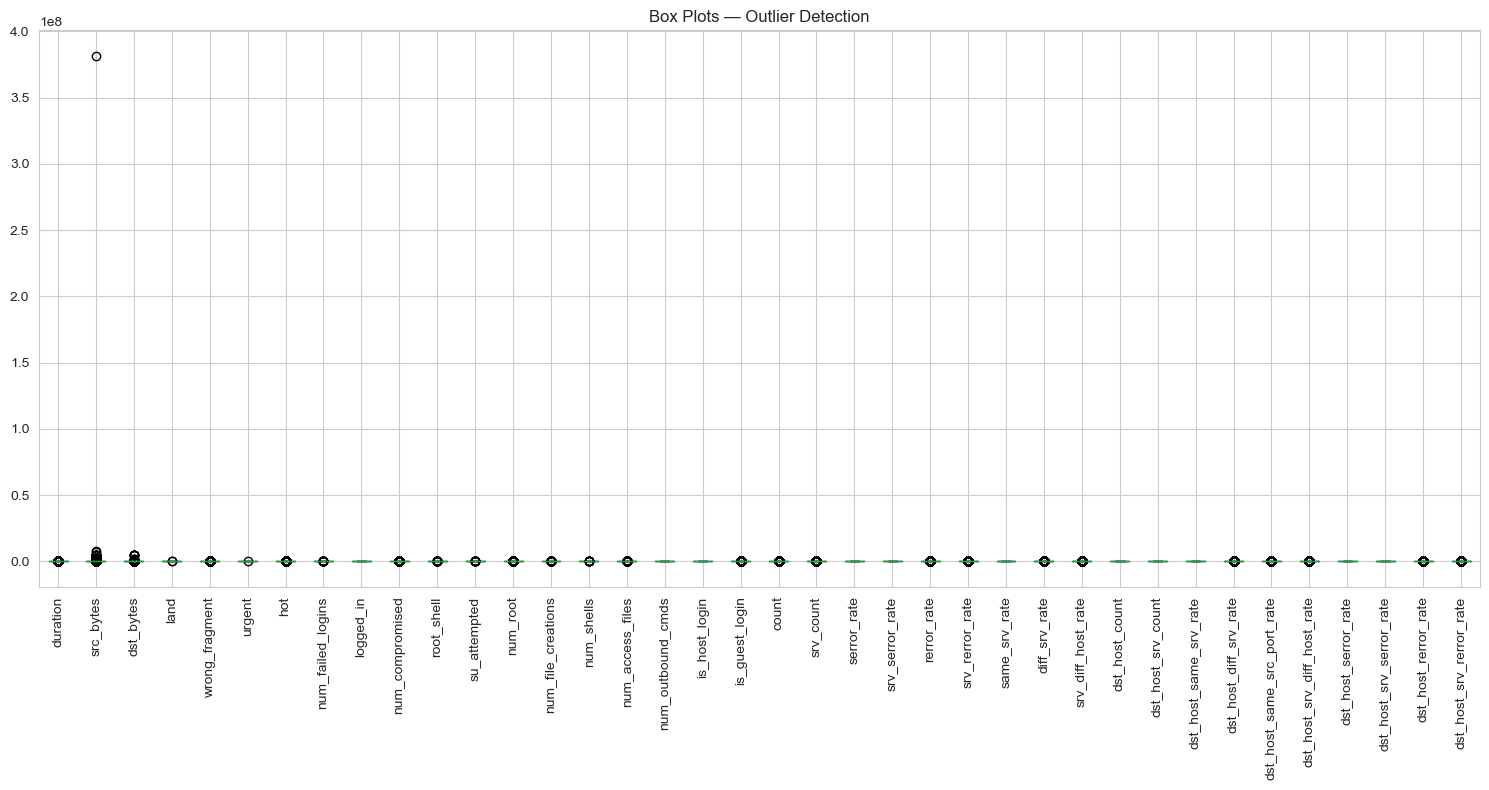

In [64]:
# TODO: Detect outliers using box plots or statistical methods.

# numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
# if numerical_cols:
#     fig, axes = plt.subplots(nrows=1, ncols=len(numerical_cols), figsize=(4 * len(numerical_cols), 5))
#     if len(numerical_cols) == 1:
#         axes = [axes]
#     for ax, col in zip(axes, numerical_cols):
#         ax.boxplot(df[col].dropna())
#         ax.set_title(col)
#     plt.suptitle('Box Plots — Outlier Detection', fontsize=14, y=1.02)
#     plt.tight_layout()
#     plt.show()
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

if numerical_cols:
    plt.figure(figsize=(15, 8))
    
    df[numerical_cols].boxplot(rot=90)
    
    plt.title('Box Plots — Outlier Detection')
    plt.tight_layout()
    plt.show()